# DeepTopic motif wall

Visualize all clustered motifs from CREsted MoDISco -> gimme cluster -> TomTom.
Adapted from `bin/3_single_task_models/3_make_motif_wall.ipynb` (ChromBPNet).

**Inputs:**
- `crested_model/motifs/meme/combined.meme` — clustered motif PWMs
- `crested_model/motifs/tfs_initial.txt` — TomTom TF annotations
- `crested_model/motifs/cluster/cluster_key.txt` — cluster membership

**Outputs:**
- `crested_model/motifs/curation/motif_logos.pdf` — motif wall
- `crested_model/motifs/curation/motif_topic_membership.pdf` — which topics each motif appears in

# Set-up

In [1]:
import os
import numpy as np
import pandas as pd
import logomaker as lm
from tangermeme.io import read_meme

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {'A': '#109648', 'C': '#255C99', 'G': '#F7B32B', 'T': '#D62839'}

In [2]:
# Paths
dataset = 'sc-islet-differentiation_10X-Multiome'
subset = 'endocrine_replicate'
base_dir = f'/cellar/users/aklie/data/datasets/{dataset}'
results_dir = f'{base_dir}/results/4_topic_models/{subset}'
motif_dir = f'{results_dir}/crested_model/motifs'

path_motif_file = f'{motif_dir}/meme/combined.meme'
path_motif_annotation = f'{motif_dir}/tfs_initial.txt'
path_cluster_key = f'{motif_dir}/cluster/cluster_key.txt'

path_out = f'{motif_dir}/curation'
os.makedirs(path_out, exist_ok=True)

# Load motifs

In [3]:
# Load motifs from MEME file
motif_dict = read_meme(path_motif_file)
motifs = list(motif_dict.items())
names = np.array([m[0] for m in motifs], dtype='U')
print(f'{len(names)} motifs loaded')

# Load TomTom annotations
initial_motifs = pd.read_csv(path_motif_annotation, sep='\t', header=None, skiprows=0)
initial_motifs.columns = ['cluster_name', 'top_tomtom_annotation', 'evalue']
annotation_dict = initial_motifs.set_index('cluster_name')['top_tomtom_annotation'].to_dict()

# Sort by e-value
df = initial_motifs.sort_values('evalue').reset_index(drop=True)
print(f'Annotations: {len(df)} motifs')
df.head()

47 motifs loaded
Annotations: 47 motifs


,cluster_name,top_tomtom_annotation,evalue
0,Average_455,ZN143_MOUSE.H11MO.0.A,3.491540e-24
1,Average_522,CTCF_MA0139.1,1.086410e-19
2,Average_503,NFYB_HUMAN.H11MO.0.A,7.941840e-14
3,Average_497,HNF4A_HUMAN.H11MO.0.A,1.304070e-11
4,Average_521,SP2_HUMAN.H11MO.0.A,1.562730e-10


In [4]:
# Load cluster key (cluster -> member patterns, which encode topic membership)
cluster_members = {}
with open(path_cluster_key) as f:
    for line in f:
        parts = line.strip().split('\t')
        cluster_name = parts[0]
        members = parts[1].split(',')
        cluster_members[cluster_name] = members

# Build cluster -> topic mapping
cluster_topics = {}
for cluster, members in cluster_members.items():
    topics = set()
    for m in members:
        # Pattern names are like Topic1.pattern_3.pfm
        topic = m.split('.')[0]
        topics.add(topic)
    cluster_topics[cluster] = sorted(topics, key=lambda x: int(x.replace('Topic', '')))

print(f'{len(cluster_topics)} clusters with topic membership')
# Show a few examples
for k in list(cluster_topics.keys())[:3]:
    ann = annotation_dict.get(k, 'Unknown').split('_')[0]
    print(f'  {k} ({ann}): {len(cluster_topics[k])} topics — {cluster_topics[k][:5]}...')

47 clusters with topic membership
  Average_516 (HNF1B): 32 topics — ['Topic2', 'Topic3', 'Topic5', 'Topic7', 'Topic9']...
  Average_464 (GATA4): 10 topics — ['Topic1', 'Topic3', 'Topic11', 'Topic29', 'Topic36']...
  Average_515 (ELK1): 15 topics — ['Topic5', 'Topic6', 'Topic8', 'Topic9', 'Topic15']...


# Motif wall — logo grid sorted by e-value

Saved motif wall (47 motifs) to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_topic_models/endocrine_replicate/crested_model/motifs/curation/motif_logos.pdf


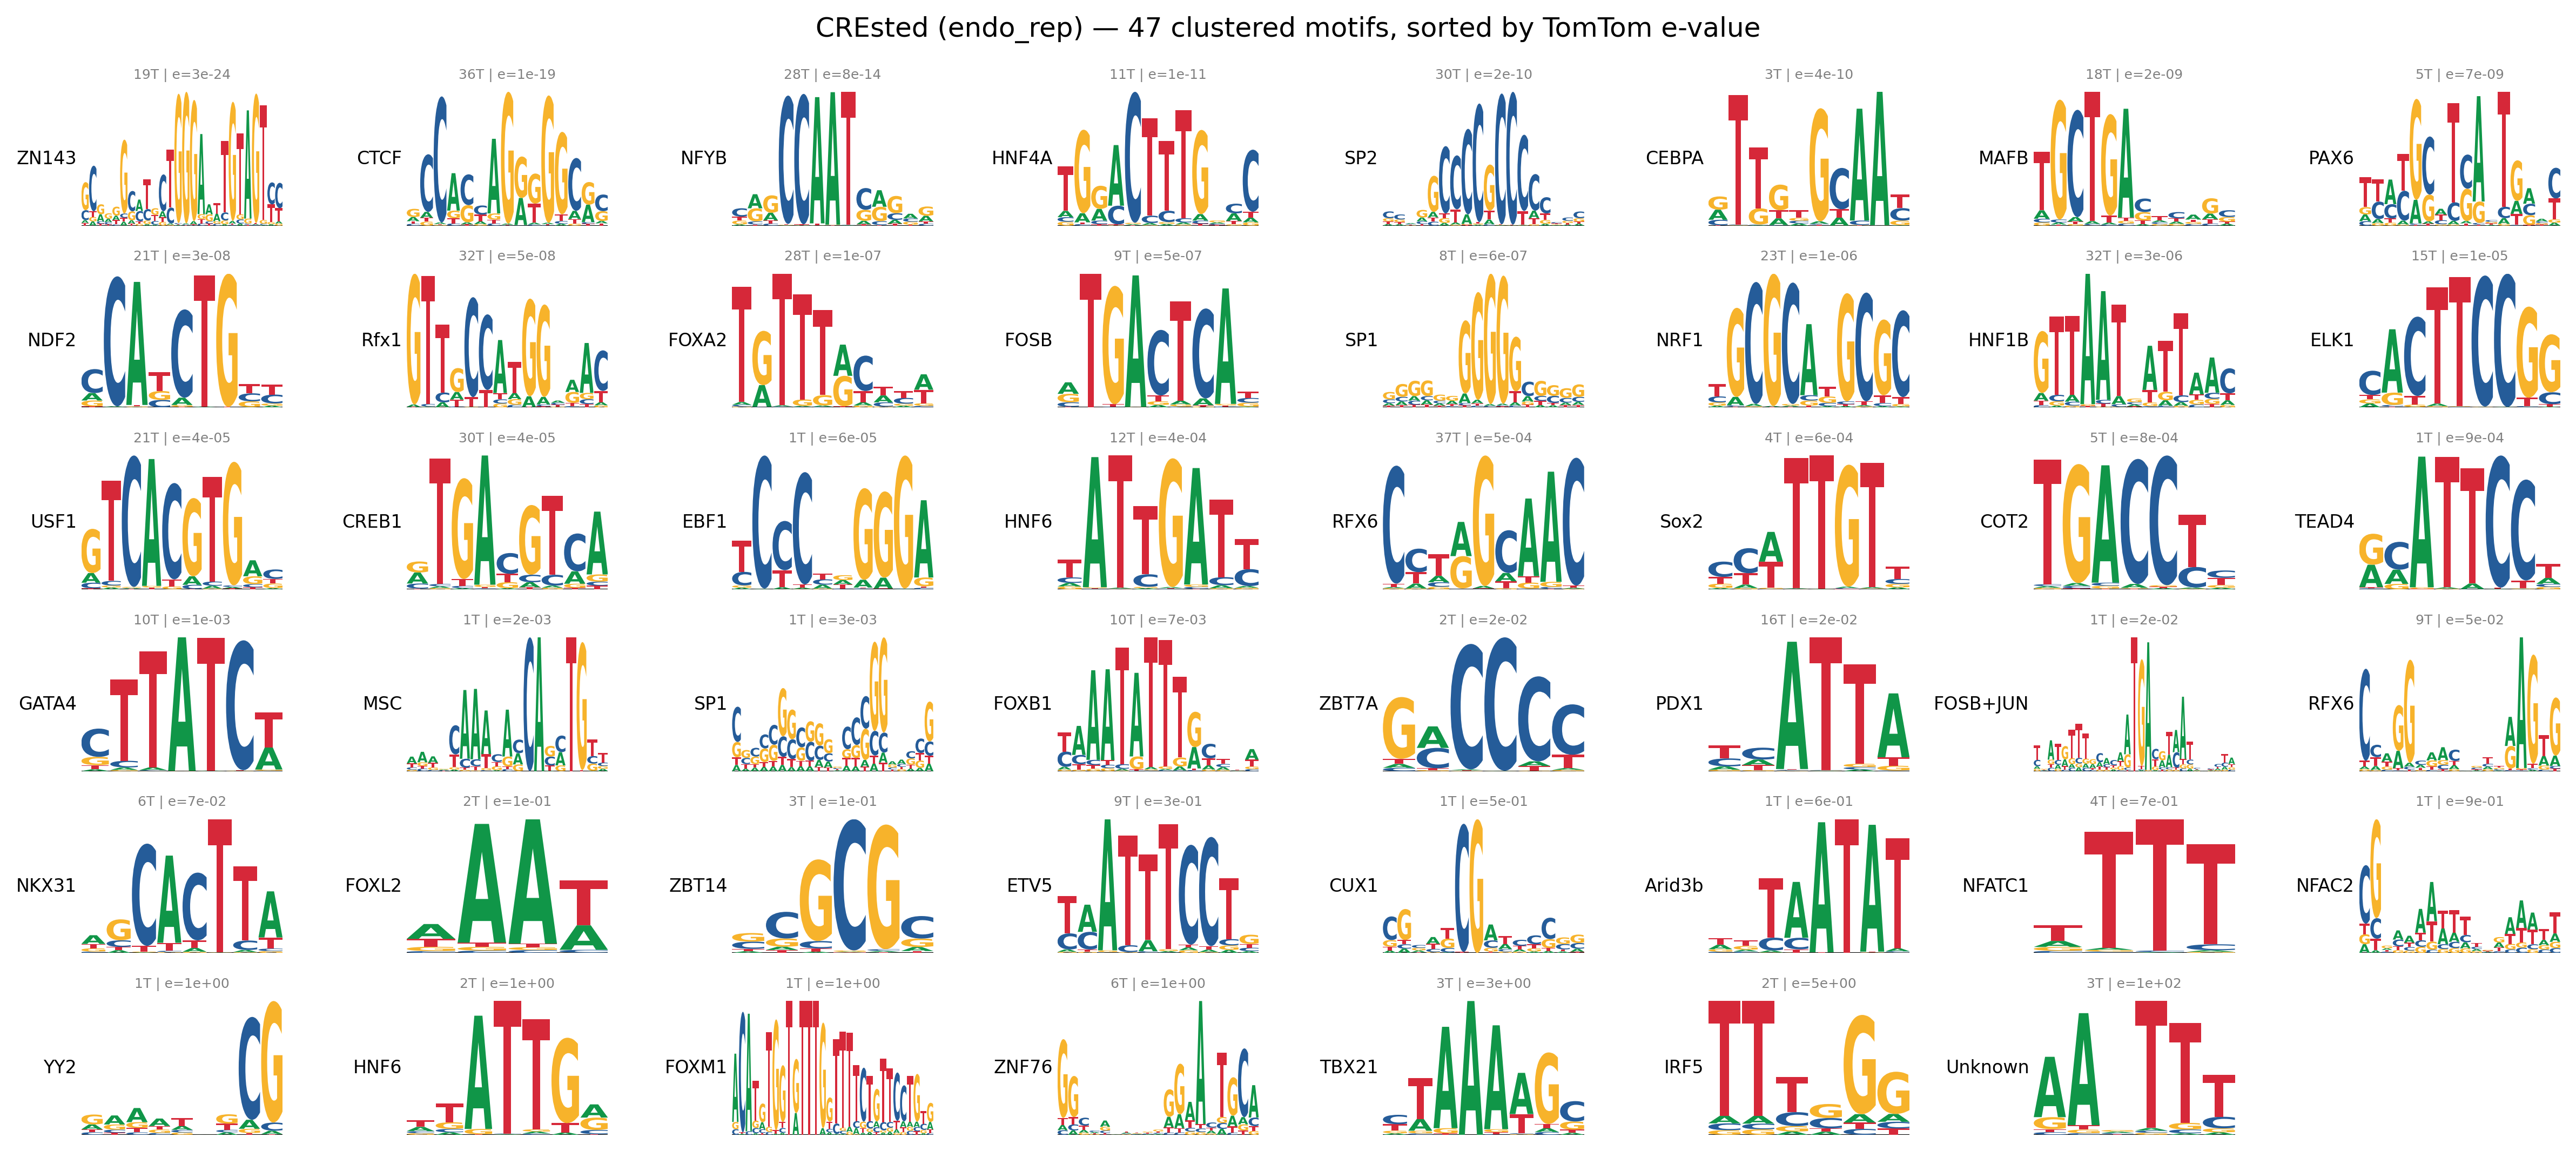

In [5]:
n_motifs = len(df)
n_cols = 8
n_rows = (n_motifs + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, n_rows * 1.2), dpi=300)
axes = axes.flatten()

for i in range(n_motifs):
    sig_motif = df['cluster_name'].iloc[i]
    annotation = annotation_dict.get(sig_motif, 'Unknown').split('_')[0]
    evalue = df['evalue'].iloc[i]
    n_topics = len(cluster_topics.get(sig_motif, []))

    ppm = motif_dict[sig_motif].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    ax = axes[i]
    lm.Logo(lm_df, ax=ax, color_scheme=LOGO_COLORS, fade_below=0.1)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(annotation, fontsize=8, rotation=0, labelpad=2, ha='right', va='center')
    ax.set_title(f'{n_topics}T | e={evalue:.0e}', fontsize=6, color='gray')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'CREsted (endo_rep) — {n_motifs} clustered motifs, sorted by TomTom e-value', fontsize=12)
plt.tight_layout()
plt.savefig(f'{path_out}/motif_logos.pdf', dpi=300, bbox_inches='tight')
print(f'Saved motif wall ({n_motifs} motifs) to {path_out}/motif_logos.pdf')
plt.show()

# Motif × topic membership heatmap

Binary matrix showing which clustered motifs appear in which topics (from MoDISco patterns).

In [6]:
# Build binary motif x topic matrix
all_topics = [f'Topic{i}' for i in range(1, 51)]
motif_order = df['cluster_name'].tolist()

membership = pd.DataFrame(0, index=motif_order, columns=all_topics)
for cluster in motif_order:
    if cluster in cluster_topics:
        for topic in cluster_topics[cluster]:
            if topic in membership.columns:
                membership.loc[cluster, topic] = 1

# Add annotation labels
motif_labels = [annotation_dict.get(m, m).split('_')[0] for m in motif_order]

print(f'Membership matrix: {membership.shape[0]} motifs x {membership.shape[1]} topics')
print(f'Motifs per topic (median): {membership.sum(axis=0).median():.0f}')
print(f'Topics per motif (median): {membership.sum(axis=1).median():.0f}')

Membership matrix: 47 motifs x 50 topics
Motifs per topic (median): 12
Topics per motif (median): 6


In [7]:
# Load topic categories for column coloring
topic_cats = pd.read_csv(f'{results_dir}/summary/topic_categories.tsv', sep='\t')
cat_colors = {
    'one-to-one': '#2ca02c',
    'lineage': '#1f77b4',
    'shared': '#ff7f0e',
    'structural': '#7f7f7f',
    'batch-driven': '#d62728',
    'unannotated': '#bcbd22',
}
topic_cat_dict = dict(zip(topic_cats['topic'], topic_cats['category']))
col_colors = [cat_colors.get(topic_cat_dict.get(t, ''), '#999999') for t in all_topics]

Saved motif x topic membership heatmap


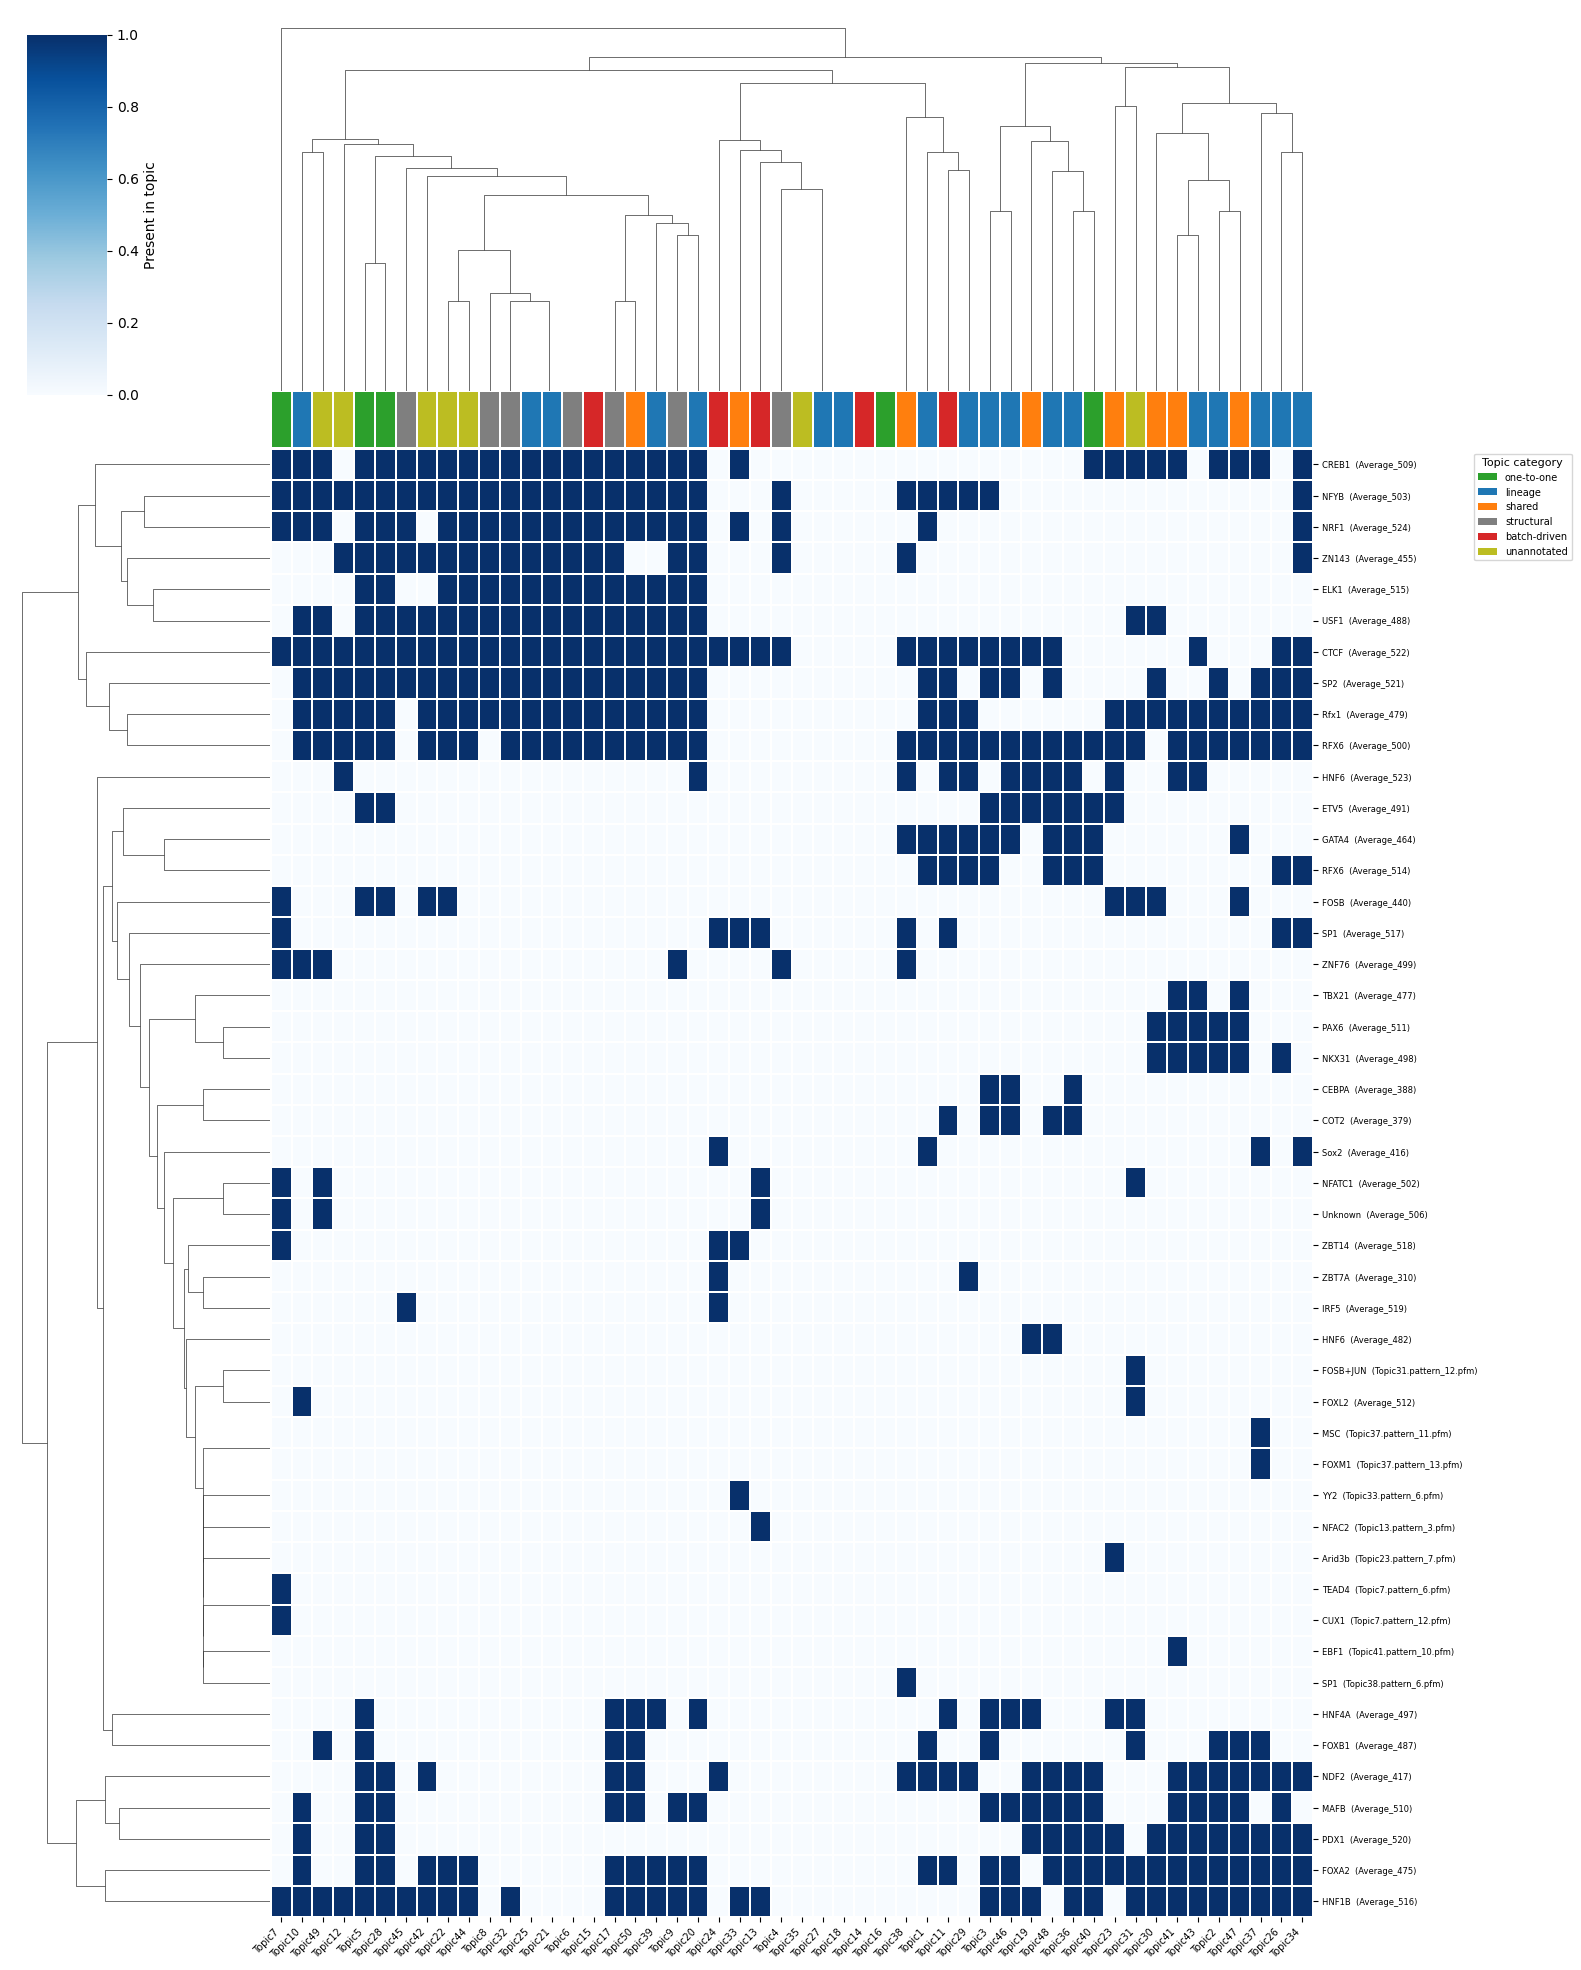

In [8]:
# Plot clustered heatmap
membership_labeled = membership.copy()
membership_labeled.index = [f'{motif_labels[i]}  ({motif_order[i]})' for i in range(len(motif_order))]

g = sns.clustermap(
    membership_labeled,
    cmap='Blues',
    figsize=(16, 20),
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    yticklabels=True,
    xticklabels=True,
    linewidths=0.1,
    cbar_kws={'label': 'Present in topic'},
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)

# Add legend for topic categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1.0),
                     title='Topic category', fontsize=7, title_fontsize=8)

plt.savefig(f'{path_out}/motif_topic_membership.pdf', dpi=300, bbox_inches='tight')
print(f'Saved motif x topic membership heatmap')
plt.show()

# Summary statistics

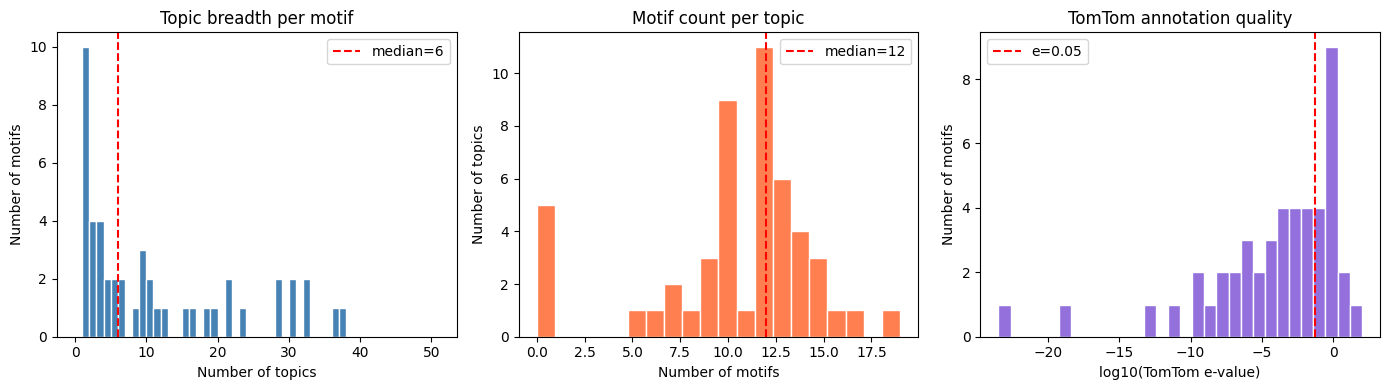

In [9]:
# Topic breadth: how many topics each motif appears in
breadth = membership.sum(axis=1)
df['n_topics'] = df['cluster_name'].map(breadth)
df['n_members'] = df['cluster_name'].map(lambda x: len(cluster_members.get(x, [])))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Topics per motif
axes[0].hist(df['n_topics'], bins=range(0, 52), color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of topics')
axes[0].set_ylabel('Number of motifs')
axes[0].set_title('Topic breadth per motif')
axes[0].axvline(df['n_topics'].median(), color='red', ls='--', label=f'median={df["n_topics"].median():.0f}')
axes[0].legend()

# Motifs per topic
motifs_per_topic = membership.sum(axis=0)
axes[1].hist(motifs_per_topic, bins=20, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of motifs')
axes[1].set_ylabel('Number of topics')
axes[1].set_title('Motif count per topic')
axes[1].axvline(motifs_per_topic.median(), color='red', ls='--', label=f'median={motifs_per_topic.median():.0f}')
axes[1].legend()

# E-value distribution
axes[2].hist(np.log10(df['evalue'].clip(lower=1e-30)), bins=30, color='mediumpurple', edgecolor='white')
axes[2].set_xlabel('log10(TomTom e-value)')
axes[2].set_ylabel('Number of motifs')
axes[2].set_title('TomTom annotation quality')
axes[2].axvline(np.log10(0.05), color='red', ls='--', label='e=0.05')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{path_out}/motif_summary_stats.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save membership matrix and summary
membership.to_csv(f'{path_out}/motif_topic_membership.csv')
df.to_csv(f'{path_out}/motif_summary.csv', index=False)
print(f'Saved to {path_out}/')

Saved to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_topic_models/endocrine_replicate/crested_model/motifs/curation/


# DONE!

---